# Baseline LSTM for BIST 100 Log Return Forecasting

**Project:** Uncertainty-Aware Financial Forecasting (COM0415 Applied Deep Learning)

**Purpose:** Interim-submission baseline. Predicts next-day BIST 100 log return using 30-day lookback over 5 features.

**Features (D=5):** BIST100 Close, S&P500 Close, CPI (CPIAUCSL), Federal Funds Rate (FEDFUNDS), Industrial Production (INDPRO)

**Target:** $r_{t+1} = \ln(P_{t+1}/P_t)$ where $P$ is BIST 100 Close

**Split:** Chronological (Train: 2010–2022, Val: 2023, Test: 2024–2026-04)

**Metrics:** MAE, RMSE, Directional Accuracy + Naive baseline ($\hat{r}=0$) for context

## Step 1: Install and Import Libraries

In [1]:
!pip install torch pandas numpy scikit-learn --quiet

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch: {torch.__version__}')

Using device: cpu
PyTorch: 2.10.0+cpu


## Step 2: Load Cleaned Dataset

Upload `financial_data.csv` (produced by `data_collection_cleaning.ipynb`) when prompted.

In [2]:
from google.colab import files
uploaded = files.upload()  # Upload financial_data.csv

df = pd.read_csv(list(uploaded.keys())[0], index_col=0, parse_dates=True)
df = df.sort_index()

# Ensure we have exactly the 5 features we expect
FEATURES = ['BIST100_Close', 'SP500_Close', 'CPIAUCSL', 'FEDFUNDS', 'INDPRO']
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    raise ValueError(f'Missing columns in dataset: {missing}')
df = df[FEATURES].dropna()

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
print(f'\nFeatures: {list(df.columns)}')
df.head()

Saving financial_data.csv to financial_data.csv
Dataset shape: (4231, 5)
Date range: 2010-01-04 to 2026-04-23

Features: ['BIST100_Close', 'SP500_Close', 'CPIAUCSL', 'FEDFUNDS', 'INDPRO']


,BIST100_Close,SP500_Close,CPIAUCSL,FEDFUNDS,INDPRO
Date,,,,,
2010-01-04,533.679199,1132.989990,217.488,0.11,89.3426
2010-01-05,541.148132,1136.520020,217.488,0.11,89.3426
2010-01-06,545.471130,1137.140015,217.488,0.11,89.3426
2010-01-07,549.726074,1141.689941,217.488,0.11,89.3426
2010-01-08,547.976074,1144.979980,217.488,0.11,89.3426


## Step 3: Construct Target (Log Returns) and Chronological Split

Target: $r_{t+1} = \ln(P_{t+1}/P_t)$ of BIST100 Close.

Split is strictly chronological (no shuffling) to avoid leakage.

In [3]:
# Compute next-day BIST log return
df['log_return_next'] = np.log(df['BIST100_Close'].shift(-1) / df['BIST100_Close'])
df = df.dropna()  # drop the last row that has NaN target

# Chronological splits
train_end = '2022-12-31'
val_end   = '2023-12-31'

train_df = df.loc[:train_end]
val_df   = df.loc[(df.index > train_end) & (df.index <= val_end)]
test_df  = df.loc[df.index > val_end]

print(f'Train: {train_df.index.min().date()} to {train_df.index.max().date()}  ({len(train_df)} rows)')
print(f'Val:   {val_df.index.min().date()} to {val_df.index.max().date()}  ({len(val_df)} rows)')
print(f'Test:  {test_df.index.min().date()} to {test_df.index.max().date()}  ({len(test_df)} rows)')

print(f'\nTarget (next-day BIST log return) stats on train set:')
print(train_df['log_return_next'].describe())

Train: 2010-01-04 to 2022-12-30  (3374 rows)
Val:   2023-01-02 to 2023-12-29  (259 rows)
Test:  2024-01-02 to 2026-04-22  (597 rows)

Target (next-day BIST log return) stats on train set:
count    3374.000000
mean        0.000700
std         0.014616
min        -0.110637
25%        -0.006211
50%         0.000907
75%         0.008859
max         0.068951
Name: log_return_next, dtype: float64


## Step 4: Feature Scaling (Fit on Train Only)

Critical: fit the scaler **only** on training data to prevent information leakage from val/test into the training process.

In [4]:
# Separate features and target
X_train_raw = train_df[FEATURES].values
X_val_raw   = val_df[FEATURES].values
X_test_raw  = test_df[FEATURES].values

y_train = train_df['log_return_next'].values.astype(np.float32)
y_val   = val_df['log_return_next'].values.astype(np.float32)
y_test  = test_df['log_return_next'].values.astype(np.float32)

scaler = StandardScaler()
scaler.fit(X_train_raw)  # fit ONLY on train

X_train = scaler.transform(X_train_raw).astype(np.float32)
X_val   = scaler.transform(X_val_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)

print(f'X_train mean (should be ~0): {X_train.mean(axis=0).round(4)}')
print(f'X_train std (should be ~1):  {X_train.std(axis=0).round(4)}')
print(f'X_val mean (may differ):     {X_val.mean(axis=0).round(4)}')

X_train mean (should be ~0): [-0. -0.  0.  0.  0.]
X_train std (should be ~1):  [1. 1. 1. 1. 1.]
X_val mean (may differ):     [7.8097 1.9025 2.9952 5.128  0.4937]


## Step 5: Build Sliding Windows (T = 30)

Each sample: 30 consecutive days of features → next-day log return.

In [5]:
LOOKBACK = 30

def make_windows(X, y, T):
    """Create sliding windows.
    X: (N, D), y: (N,)
    Returns: X_win (N-T+1, T, D), y_win (N-T+1,)
    The target for window ending at index i is y[i].
    """
    X_win, y_win = [], []
    for i in range(T - 1, len(X)):
        X_win.append(X[i - T + 1 : i + 1])
        y_win.append(y[i])
    return np.stack(X_win), np.array(y_win, dtype=np.float32)

X_train_w, y_train_w = make_windows(X_train, y_train, LOOKBACK)
X_val_w,   y_val_w   = make_windows(X_val,   y_val,   LOOKBACK)
X_test_w,  y_test_w  = make_windows(X_test,  y_test,  LOOKBACK)

print(f'Train windows: X {X_train_w.shape}, y {y_train_w.shape}')
print(f'Val windows:   X {X_val_w.shape}, y {y_val_w.shape}')
print(f'Test windows:  X {X_test_w.shape}, y {y_test_w.shape}')

Train windows: X (3345, 30, 5), y (3345,)
Val windows:   X (230, 30, 5), y (230,)
Test windows:  X (568, 30, 5), y (568,)


## Step 6: PyTorch Dataset and DataLoaders

In [6]:
class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

BATCH = 64
train_loader = DataLoader(TSDataset(X_train_w, y_train_w), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TSDataset(X_val_w,   y_val_w),   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(TSDataset(X_test_w,  y_test_w),  batch_size=BATCH, shuffle=False)

print(f'Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')

Batches: train=53, val=4, test=9


## Step 7: Define LSTM Baseline Model

In [7]:
class LSTMBaseline(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        out, _ = self.lstm(x)       # (B, T, H)
        last = out[:, -1, :]         # take last timestep (B, H)
        return self.head(last).squeeze(-1)  # (B,)

model = LSTMBaseline(input_dim=len(FEATURES), hidden_dim=64, num_layers=2, dropout=0.2).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {n_params:,}')

LSTMBaseline(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 53,569


## Step 8: Train with Early Stopping on Validation Loss

In [8]:
EPOCHS = 50
LR = 1e-3
PATIENCE = 7

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = float('inf')
best_state = None
wait = 0
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    train_losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    # Validate
    model.eval()
    val_losses = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            val_losses.append(criterion(pred, yb).item())

    tl, vl = np.mean(train_losses), np.mean(val_losses)
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    print(f'Epoch {epoch:3d} | Train MSE: {tl:.6f} | Val MSE: {vl:.6f}')

    if vl < best_val:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} (best val MSE: {best_val:.6f})')
            break

# Restore best weights
model.load_state_dict(best_state)
print(f'\n✅ Training complete. Best val MSE: {best_val:.6f}')

Epoch   1 | Train MSE: 0.001876 | Val MSE: 0.000434
Epoch   2 | Train MSE: 0.000379 | Val MSE: 0.000509
Epoch   3 | Train MSE: 0.000385 | Val MSE: 0.000480
Epoch   4 | Train MSE: 0.000345 | Val MSE: 0.000437
Epoch   5 | Train MSE: 0.000322 | Val MSE: 0.000442
Epoch   6 | Train MSE: 0.000302 | Val MSE: 0.000434
Epoch   7 | Train MSE: 0.000275 | Val MSE: 0.000448
Epoch   8 | Train MSE: 0.000267 | Val MSE: 0.000446
Epoch   9 | Train MSE: 0.000258 | Val MSE: 0.000433
Epoch  10 | Train MSE: 0.000248 | Val MSE: 0.000462
Epoch  11 | Train MSE: 0.000235 | Val MSE: 0.000430
Epoch  12 | Train MSE: 0.000236 | Val MSE: 0.000458
Epoch  13 | Train MSE: 0.000230 | Val MSE: 0.000473
Epoch  14 | Train MSE: 0.000224 | Val MSE: 0.000450
Epoch  15 | Train MSE: 0.000221 | Val MSE: 0.000446
Epoch  16 | Train MSE: 0.000215 | Val MSE: 0.000458
Epoch  17 | Train MSE: 0.000215 | Val MSE: 0.000469
Epoch  18 | Train MSE: 0.000213 | Val MSE: 0.000452

Early stopping at epoch 18 (best val MSE: 0.000430)

✅ Training

## Step 9: Evaluate on Test Set + Naive Baseline Comparison

In [9]:
def predict(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            preds.append(model(Xb).cpu().numpy())
            trues.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(trues)

def eval_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Directional accuracy: sign agreement, ignoring exactly-zero actuals
    mask = y_true != 0
    if mask.sum() > 0:
        dir_acc = (np.sign(y_pred[mask]) == np.sign(y_true[mask])).mean() * 100
    else:
        dir_acc = float('nan')
    print(f'{label:20s} | MAE: {mae:.6f} | RMSE: {rmse:.6f} | Dir. Acc: {dir_acc:.2f}%')
    return mae, rmse, dir_acc

# LSTM on test
y_pred_lstm, y_true = predict(model, test_loader)

# Naive baseline: predict r = 0 (i.e., price unchanged)
y_pred_naive = np.zeros_like(y_true)

print('=' * 72)
print('TEST SET RESULTS')
print('=' * 72)
m_naive = eval_metrics(y_true, y_pred_naive, 'Naive (r̂=0)')
m_lstm  = eval_metrics(y_true, y_pred_lstm,  'LSTM Baseline')
print('=' * 72)

# Improvement over naive
mae_impr  = (m_naive[0] - m_lstm[0]) / m_naive[0] * 100
rmse_impr = (m_naive[1] - m_lstm[1]) / m_naive[1] * 100
print(f'\nLSTM improvement over naive baseline:')
print(f'  MAE:  {mae_impr:+.2f}%   ({"better" if mae_impr > 0 else "worse"})')
print(f'  RMSE: {rmse_impr:+.2f}%  ({"better" if rmse_impr > 0 else "worse"})')
print(f'\nNote: On daily equity log returns, even small improvements over a naive')
print(f'baseline are considered meaningful due to the low signal-to-noise ratio.')

TEST SET RESULTS
Naive (r̂=0)         | MAE: 0.010781 | RMSE: 0.014858 | Dir. Acc: 0.00%
LSTM Baseline        | MAE: 0.011158 | RMSE: 0.015193 | Dir. Acc: 48.63%

LSTM improvement over naive baseline:
  MAE:  -3.50%   (worse)
  RMSE: -2.25%  (worse)

Note: On daily equity log returns, even small improvements over a naive
baseline are considered meaningful due to the low signal-to-noise ratio.


## Step 10: Save Results for the Interim Report

In [10]:
results = pd.DataFrame([
    {'Model': 'Naive Baseline (r̂=0)', 'MAE': m_naive[0], 'RMSE': m_naive[1], 'Dir. Acc (%)': m_naive[2]},
    {'Model': 'LSTM Baseline',         'MAE': m_lstm[0],  'RMSE': m_lstm[1],  'Dir. Acc (%)': m_lstm[2]},
])
print(results.to_string(index=False))

results.to_csv('baseline_results.csv', index=False)
print('\n✅ Saved baseline_results.csv')

# Also save training curve for optional plot
hist_df = pd.DataFrame(history)
hist_df.to_csv('training_history.csv', index=False)
print('✅ Saved training_history.csv')

                Model      MAE     RMSE  Dir. Acc (%)
Naive Baseline (r̂=0) 0.010781 0.014858      0.000000
        LSTM Baseline 0.011158 0.015193     48.628885

✅ Saved baseline_results.csv
✅ Saved training_history.csv


## Step 11: (Optional) Visualize Predictions vs. Actuals

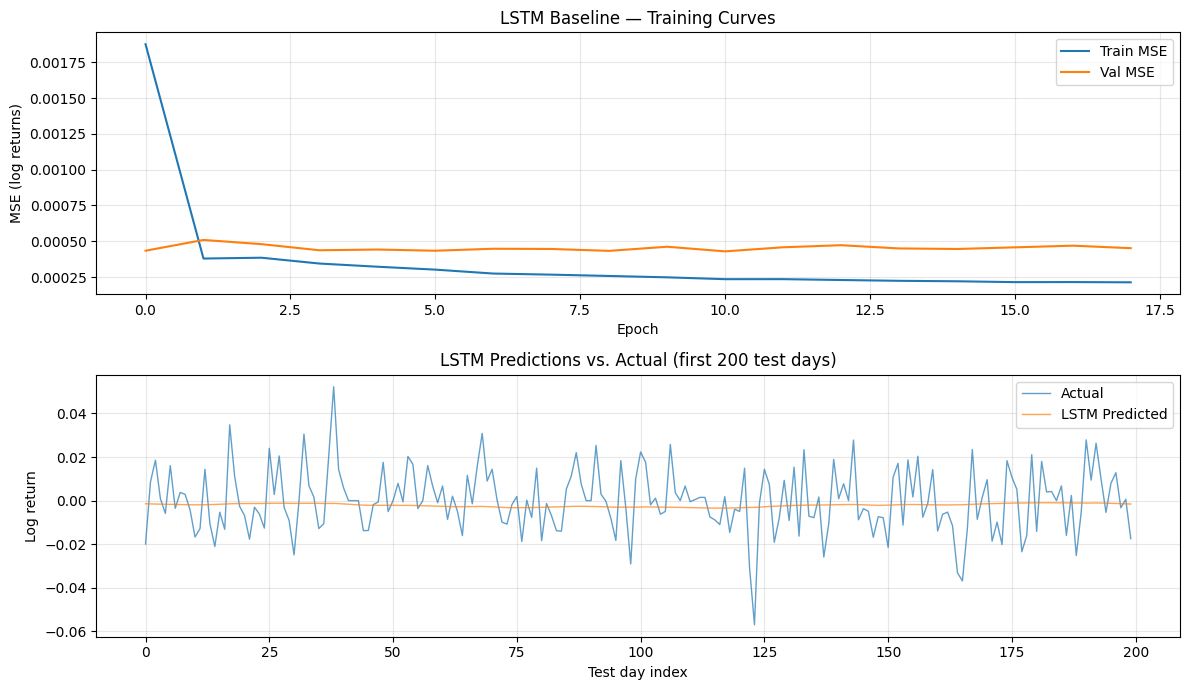

✅ Saved lstm_baseline_plot.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Training curves
axes[0].plot(history['train_loss'], label='Train MSE')
axes[0].plot(history['val_loss'], label='Val MSE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (log returns)')
axes[0].set_title('LSTM Baseline — Training Curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Predictions vs actuals on test set (first 200 days for readability)
n_show = min(200, len(y_true))
axes[1].plot(y_true[:n_show], label='Actual', alpha=0.7, linewidth=1)
axes[1].plot(y_pred_lstm[:n_show], label='LSTM Predicted', alpha=0.7, linewidth=1)
axes[1].set_xlabel('Test day index')
axes[1].set_ylabel('Log return')
axes[1].set_title(f'LSTM Predictions vs. Actual (first {n_show} test days)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_baseline_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved lstm_baseline_plot.png')